# ICA12 — Comparing mesoscale and large-eddy simulations

This streamlined notebook keeps the same three plot types as the original notebook, but uses:

- one shared configuration block
- one shared set of helper functions
- consistent naming for simulations, domains, and colors
- reusable plotting logic instead of repeated definitions


In [8]:
# Core imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path


In [9]:
# -----------------------------
# Shared configuration
# -----------------------------
BASE_DIR = Path("/scratch/alpine/jlundqui/NWP/ICA12/IdealizedSimulations")

SIM_NAMES = ["sst_26", "sst_27", "sst_30", "sst_31", "sst_32"]
PANEL_TITLES = ["Category 1", "Category 2", "Category 3", "Category 4", "Category 5"]
PANEL_COLORS = ["tab:blue", "tab:green", "#D8A106", "tab:red", "tab:purple"]

DOMAIN_INFO = {
    "d01": {"label": "Mesoscale", "linestyle": "--", "dr_m": 1500.0},
    "d02": {"label": "LES",       "linestyle": "-",  "dr_m": 55.5},
}
DOMAIN_ORDER = ["d01", "d02"]

# Radius of maximum winds [km] for each simulation/domain
RMAX_WIND_KM = {
    "sst_26": {"d01": 25.5, "d02": 26.33},
    "sst_27": {"d01": 22.5, "d02": 21.33},
    "sst_30": {"d01": 19.5, "d02": 21.33},
    "sst_31": {"d01": 24.0, "d02": 25.16},
    "sst_32": {"d01": 24.0, "d02": 22.33},
}

RHAT_MIN = 0.8
RHAT_MAX = 1.2
YMAX_PROFILE_M = 1500.0


In [10]:
# -----------------------------
# Shared helper functions
# -----------------------------
def open_case(sim_name, domain, base_dir=BASE_DIR):
    path = base_dir / sim_name / f"azmth_{domain}.nc"
    if not path.exists():
        raise FileNotFoundError(f"Could not find {path}")
    return xr.open_dataset(path)


def get_level_index(z, target_height_m):
    z = np.asarray(z, dtype=float)
    return int(np.nanargmin(np.abs(z - target_height_m)))


def angle_to_radians(a):
    a = np.asarray(a, dtype=float)
    if np.nanmax(np.abs(a)) <= 2 * np.pi + 0.1:
        return a
    return np.deg2rad(a)


def close_angular_seam(a_rad, field2d):
    a_closed = np.concatenate([a_rad, [a_rad[0] + 2 * np.pi]])
    field_closed = np.vstack([field2d, field2d[0:1, :]])
    return a_closed, field_closed


def polar_to_xy(a_rad, r_km):
    A, R = np.meshgrid(a_rad, r_km, indexing="ij")
    X = R * np.cos(A)
    Y = R * np.sin(A)
    return X, Y


def convert_r_to_meters(r, domain):
    """Convert r to meters, but avoid multiplying if it already looks physical."""
    r = np.asarray(r, dtype=float)
    diffs = np.diff(r)
    diffs = diffs[np.isfinite(diffs)]
    if len(diffs) == 0:
        return r

    median_dr = np.nanmedian(np.abs(diffs))
    nominal_dr = DOMAIN_INFO[domain]["dr_m"]

    if np.isclose(median_dr, nominal_dr, rtol=0.05, atol=1e-6):
        return r
    if np.isclose(median_dr, 1.0, rtol=0.05, atol=1e-6):
        return r * nominal_dr
    if np.nanmax(r) > 1e4:
        return r
    return r * nominal_dr


def get_common_rmax_m(sim_names=SIM_NAMES, domains=DOMAIN_ORDER):
    common_rmax_m = np.inf
    for sim in sim_names:
        for dom in domains:
            with open_case(sim, dom) as ds:
                r_m = convert_r_to_meters(ds["r"].values, dom)
                common_rmax_m = min(common_rmax_m, np.nanmax(r_m))
    return common_rmax_m


def azimuthal_mean_profile(ds, varname, target_height_m, domain, common_rmax_m=None):
    """Return azimuthally averaged profile versus radius at a requested height."""
    z = ds["z"].values
    r_m = convert_r_to_meters(ds["r"].values, domain)
    k = get_level_index(z, target_height_m)

    field = ds[varname].isel(z=k).values  # (a, r)
    profile = np.nanmean(field, axis=0)

    if common_rmax_m is not None:
        keep = r_m <= common_rmax_m
        r_m = r_m[keep]
        profile = profile[keep]

    return r_m / 1000.0, profile, float(z[k])


def radial_azimuthal_mean_profile(ds, varname, domain, rmin_m, rmax_m):
    """Return a vertical profile averaged over azimuth and a radial band."""
    z = np.asarray(ds["z"].values, dtype=float)
    r_m = convert_r_to_meters(ds["r"].values, domain)

    keep_r = (r_m >= rmin_m) & (r_m <= rmax_m)
    if not np.any(keep_r):
        raise ValueError(
            f"No radii found in requested range {rmin_m/1000:.2f}–{rmax_m/1000:.2f} km for {domain}"
        )

    field = ds[varname].values[:, :, keep_r]   # (a, z, r_subset)
    profile = np.nanmean(field, axis=0)        # (z, r_subset)
    profile = np.nanmean(profile, axis=1)      # (z,)
    return z, profile


def interp_to_common_z(z1, p1, z2, p2, nz=300):
    """Interpolate two vertical profiles onto their overlapping z range."""
    zmin = max(np.nanmin(z1), np.nanmin(z2))
    zmax = min(np.nanmax(z1), np.nanmax(z2))
    if zmax <= zmin:
        raise ValueError("No overlapping z range between the two domains.")

    z_common = np.linspace(zmin, zmax, nz)
    p1i = np.interp(z_common, z1, p1)
    p2i = np.interp(z_common, z2, p2)
    return z_common, p1i, p2i


def get_rhat_band_m(sim_name, domain, rhat_min=RHAT_MIN, rhat_max=RHAT_MAX):
    r0_km = RMAX_WIND_KM[sim_name][domain]
    return 1000.0 * rhat_min * r0_km, 1000.0 * rhat_max * r0_km


## 1. Horizontal wind speed maps at one altitude (Figure 4b,d)

/tmp/ipykernel_4000280/3491341264.py:70: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mappable = ax.pcolormesh(


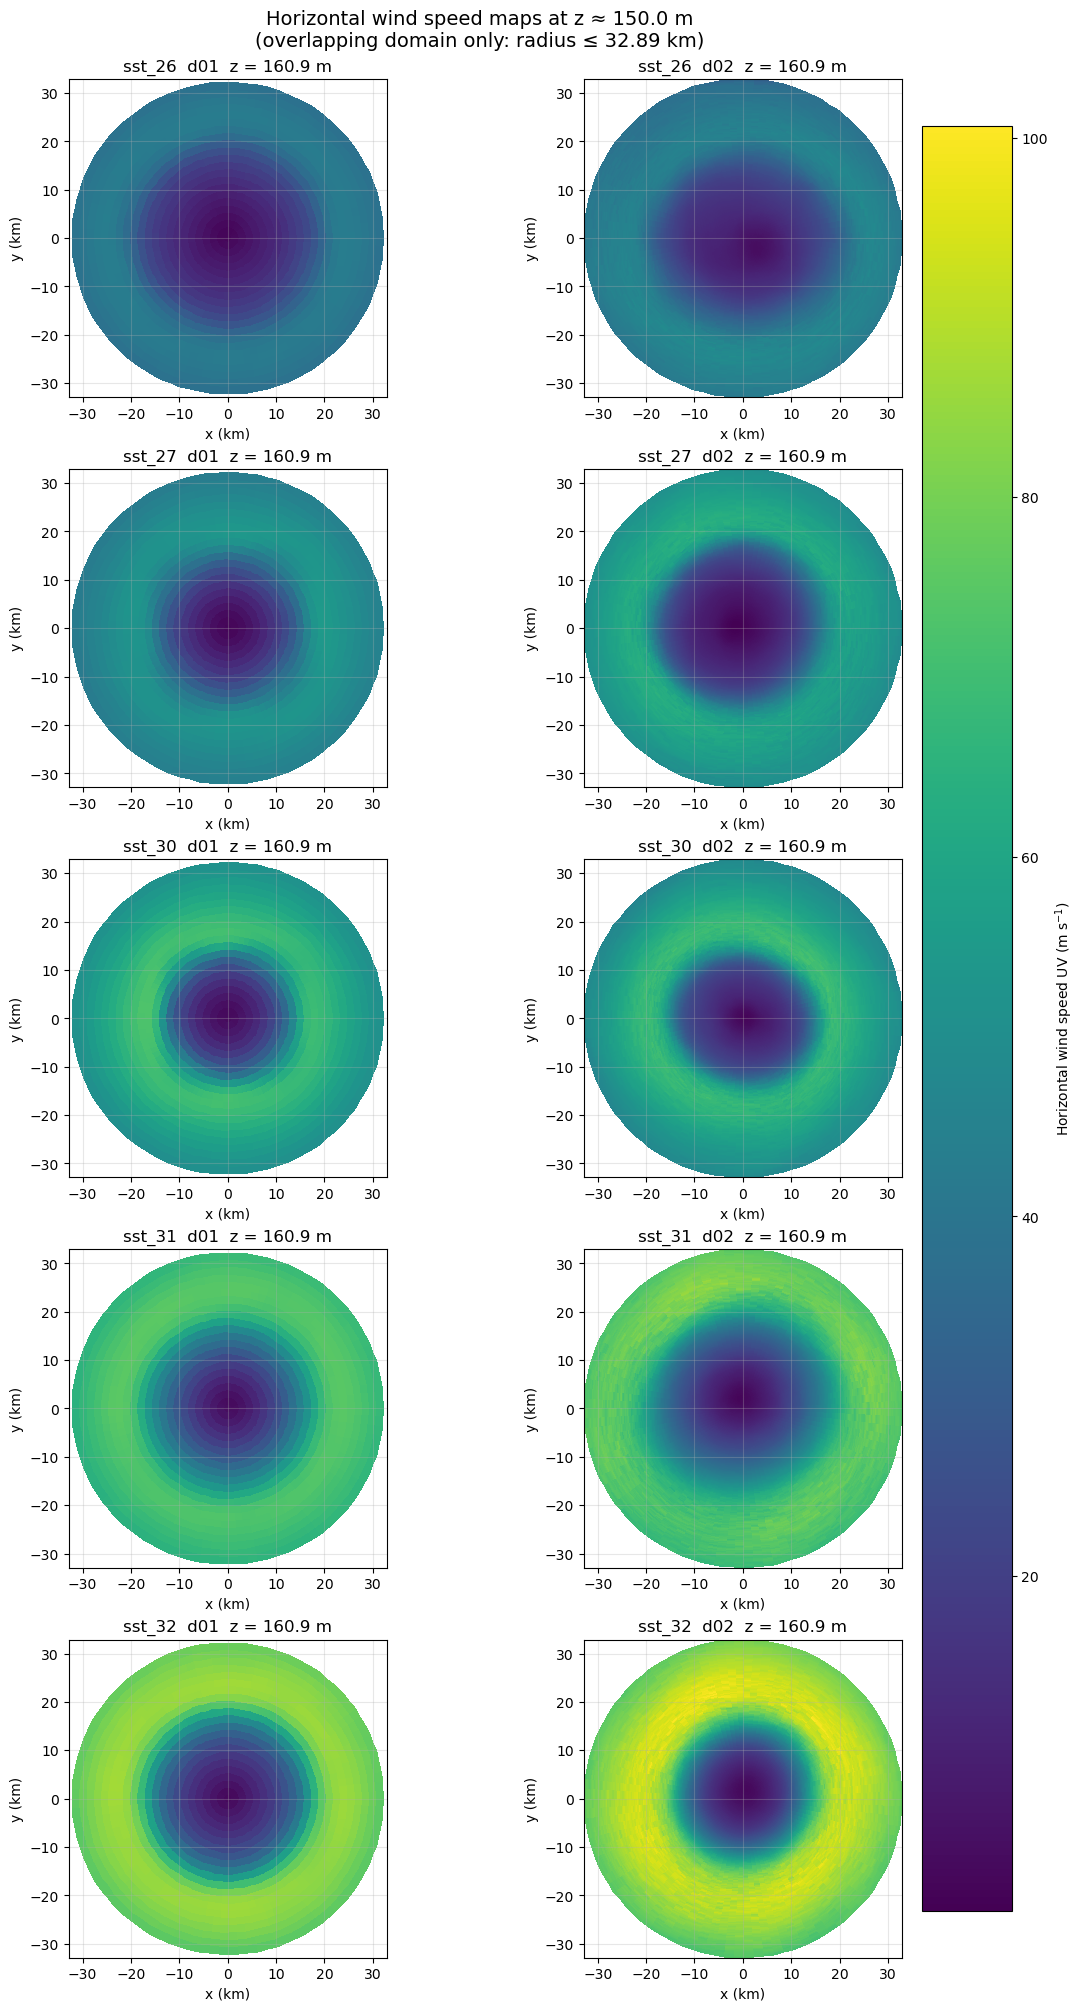

In [11]:
target_height_m = 150.0
varname = "UV"
cmap = "viridis"
outfile = "horizontal_wind_speed_maps_overlap.png"

common_rmax_m = get_common_rmax_m()
common_rmax_km = common_rmax_m / 1000.0

# determine shared color scale over overlapping region only
vmin = np.inf
vmax = -np.inf

for sim in SIM_NAMES:
    for dom in DOMAIN_ORDER:
        with open_case(sim, dom) as ds:
            z = ds["z"].values
            r_m = convert_r_to_meters(ds["r"].values, dom)
            keep = r_m <= common_rmax_m
            if not np.any(keep):
                continue

            k = get_level_index(z, target_height_m)
            fld = ds[varname].isel(z=k).values[:, keep]
            if np.all(np.isnan(fld)):
                continue

            vmin = min(vmin, np.nanmin(fld))
            vmax = max(vmax, np.nanmax(fld))

fig, axes = plt.subplots(
    nrows=len(SIM_NAMES),
    ncols=len(DOMAIN_ORDER),
    figsize=(12, 4 * len(SIM_NAMES)),
    constrained_layout=True
)

if len(SIM_NAMES) == 1:
    axes = np.array([axes])

mappable = None

for i, sim in enumerate(SIM_NAMES):
    for j, dom in enumerate(DOMAIN_ORDER):
        ax = axes[i, j]

        with open_case(sim, dom) as ds:
            a = ds["a"].values
            z = ds["z"].values
            r_m = convert_r_to_meters(ds["r"].values, dom)
            r_km = r_m / 1000.0

            keep = r_m <= common_rmax_m
            if not np.any(keep):
                ax.set_title(f"{sim}  {dom}  no overlapping data")
                ax.set_xlim(-common_rmax_km, common_rmax_km)
                ax.set_ylim(-common_rmax_km, common_rmax_km)
                ax.set_aspect("equal")
                ax.set_xlabel("x (km)")
                ax.set_ylabel("y (km)")
                continue

            r_km_sub = r_km[keep]
            k = get_level_index(z, target_height_m)
            field = ds[varname].isel(z=k).values[:, keep]

        a_rad = angle_to_radians(a)
        a_closed, field_closed = close_angular_seam(a_rad, field)
        X, Y = polar_to_xy(a_closed, r_km_sub)

        mappable = ax.pcolormesh(
            X, Y, field_closed,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )

        ax.set_aspect("equal")
        ax.set_xlim(-common_rmax_km, common_rmax_km)
        ax.set_ylim(-common_rmax_km, common_rmax_km)
        ax.set_xlabel("x (km)")
        ax.set_ylabel("y (km)")
        ax.set_title(f"{sim}  {dom}  z = {z[k]:.1f} m")
        ax.grid(True, alpha=0.3)

cbar = fig.colorbar(mappable, ax=axes, shrink=0.95, pad=0.02)
cbar.set_label("Horizontal wind speed UV (m s$^{-1}$)")

fig.suptitle(
    f"Horizontal wind speed maps at z ≈ {target_height_m:.1f} m\n"
    f"(overlapping domain only: radius ≤ {common_rmax_km:.2f} km)",
    fontsize=14
)

fig.savefig(outfile, dpi=200, bbox_inches="tight")
plt.show()


## 2. Azimuthally averaged horizontal wind speed as a function of radius at 10 m (Figure 6)

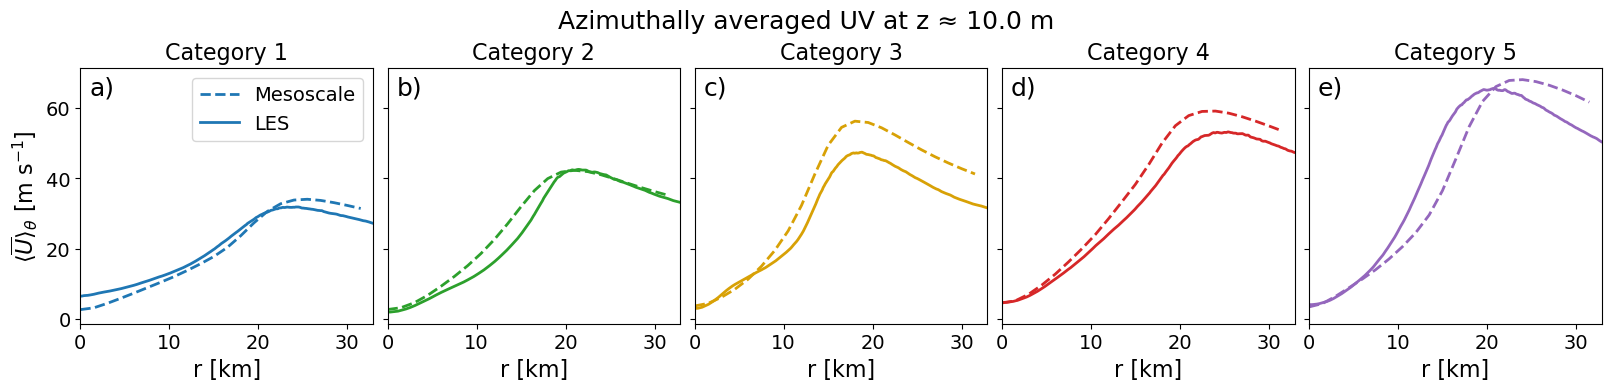

In [16]:
target_height_m = 10.0
varname = "UV"
outfile = "azimuthal_mean_uv_vs_r.png"

common_rmax_m = get_common_rmax_m()
common_rmax_km = common_rmax_m / 1000.0
letters = ["a)", "b)", "c)", "d)", "e)"]

fig, axes = plt.subplots(
    1, len(SIM_NAMES),
    figsize=(16, 3.8),
    sharey=True,
    constrained_layout=True
)

if len(SIM_NAMES) == 1:
    axes = [axes]

for i, sim in enumerate(SIM_NAMES):
    ax = axes[i]
    color = PANEL_COLORS[i]

    for dom in DOMAIN_ORDER:
        with open_case(sim, dom) as ds:
            r_km, profile, z_used = azimuthal_mean_profile(
                ds, varname, target_height_m, dom, common_rmax_m=common_rmax_m
            )

        ax.plot(
            r_km, profile,
            linestyle=DOMAIN_INFO[dom]["linestyle"],
            linewidth=2.0,
            color=color,
            label=DOMAIN_INFO[dom]["label"]
        )

    ax.set_title(PANEL_TITLES[i], fontsize=16)
    ax.set_xlim(0, common_rmax_km)
    ax.set_xlabel("r [km]", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.text(0.03, 0.97, letters[i], transform=ax.transAxes, ha="left", va="top", fontsize=18)

    if i == 0:
        ax.set_ylabel(r"$\langle \overline{U} \rangle_{\theta}$ [m s$^{-1}$]", fontsize=16)
        ax.legend(frameon=True, fontsize=14)

fig.suptitle(f"Azimuthally averaged {varname} at z ≈ {target_height_m:.1f} m", fontsize=18)
fig.savefig(outfile, dpi=200, bbox_inches="tight")
plt.show()


## 3. Time- and azimuth-averaged tangential and radial velocity profiles in the eyewall region (Figure 11)

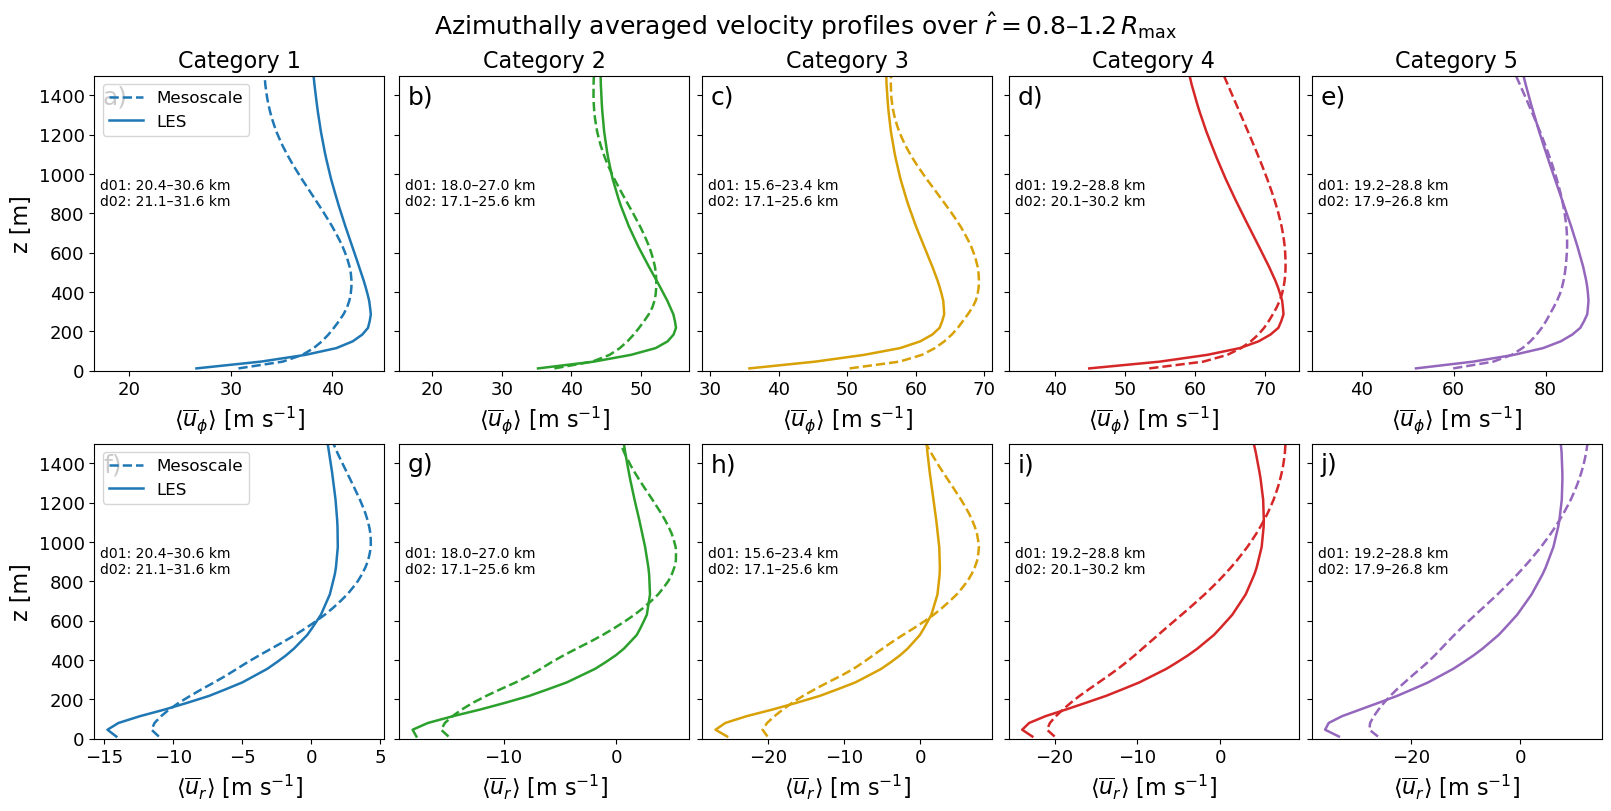

In [20]:
outfile = "Ut_Un_vertical_profiles_rhat08_12.png"
letters_top = ["a)", "b)", "c)", "d)", "e)"]
letters_bot = ["f)", "g)", "h)", "i)", "j)"]

fig, axes = plt.subplots(
    2, len(SIM_NAMES),
    figsize=(16, 8),
    sharey=True,
    constrained_layout=True
)

for i, sim in enumerate(SIM_NAMES):
    color = PANEL_COLORS[i]

    with open_case(sim, "d01") as ds_d01, open_case(sim, "d02") as ds_d02:
        rmin_d01_m, rmax_d01_m = get_rhat_band_m(sim, "d01")
        rmin_d02_m, rmax_d02_m = get_rhat_band_m(sim, "d02")

        # Tangential velocity
        z1_ut, ut1 = radial_azimuthal_mean_profile(ds_d01, "Ut", "d01", rmin_d01_m, rmax_d01_m)
        z2_ut, ut2 = radial_azimuthal_mean_profile(ds_d02, "Ut", "d02", rmin_d02_m, rmax_d02_m)
        z_ut, ut1i, ut2i = interp_to_common_z(z1_ut, ut1, z2_ut, ut2)

        ax = axes[0, i]
        ax.plot(ut1i, z_ut, linestyle=DOMAIN_INFO["d01"]["linestyle"], color=color, linewidth=1.8, label="Mesoscale")
        ax.plot(ut2i, z_ut, linestyle=DOMAIN_INFO["d02"]["linestyle"], color=color, linewidth=1.8, label="LES")
        ax.set_title(PANEL_TITLES[i], fontsize=16)
        ax.text(0.03, 0.97, letters_top[i], transform=ax.transAxes, ha="left", va="top", fontsize=18)
        ax.tick_params(labelsize=13)
        ax.set_xlabel(r"$\langle \overline{u}_{\phi} \rangle$ [m s$^{-1}$]", fontsize=16)
        ax.set_ylim(0, YMAX_PROFILE_M)
        if i == 0:
            ax.set_ylabel("z [m]", fontsize=16)
            ax.legend(frameon=True, fontsize=12)
        ax.text(
            0.47, 0.55,
            f"d01: {RHAT_MIN * RMAX_WIND_KM[sim]['d01']:.1f}–{RHAT_MAX * RMAX_WIND_KM[sim]['d01']:.1f} km\n"
            f"d02: {RHAT_MIN * RMAX_WIND_KM[sim]['d02']:.1f}–{RHAT_MAX * RMAX_WIND_KM[sim]['d02']:.1f} km",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=10
        )

        # Radial velocity
        z1_un, un1 = radial_azimuthal_mean_profile(ds_d01, "Un", "d01", rmin_d01_m, rmax_d01_m)
        z2_un, un2 = radial_azimuthal_mean_profile(ds_d02, "Un", "d02", rmin_d02_m, rmax_d02_m)
        z_un, un1i, un2i = interp_to_common_z(z1_un, un1, z2_un, un2)

        ax = axes[1, i]
        ax.plot(un1i, z_un, linestyle=DOMAIN_INFO["d01"]["linestyle"], color=color, linewidth=1.8, label="Mesoscale")
        ax.plot(un2i, z_un, linestyle=DOMAIN_INFO["d02"]["linestyle"], color=color, linewidth=1.8, label="LES")
        ax.text(0.03, 0.97, letters_bot[i], transform=ax.transAxes, ha="left", va="top", fontsize=18)
        ax.tick_params(labelsize=13)
        ax.set_xlabel(r"$\langle \overline{u}_{r} \rangle$ [m s$^{-1}$]", fontsize=16)
        ax.set_ylim(0, YMAX_PROFILE_M)
        if i == 0:
            ax.set_ylabel("z [m]", fontsize=16)
            ax.legend(frameon=True, fontsize=12)
        ax.text(
            0.47, 0.55,
            f"d01: {RHAT_MIN * RMAX_WIND_KM[sim]['d01']:.1f}–{RHAT_MAX * RMAX_WIND_KM[sim]['d01']:.1f} km\n"
            f"d02: {RHAT_MIN * RMAX_WIND_KM[sim]['d02']:.1f}–{RHAT_MAX * RMAX_WIND_KM[sim]['d02']:.1f} km",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=10
        )

# fig.suptitle(
#     rf"Azimuthally averaged velocity profiles over $\hat{{r}}={RHAT_MIN:.1f}$–{RHAT_MAX:.1f}\,R_{{\max}}$",
#     fontsize=18
# )

fig.suptitle(
    rf"Azimuthally averaged velocity profiles over "
    rf"$\hat{{r}}={RHAT_MIN:.1f}$–{RHAT_MAX:.1f}$\,R_{{\max}}$",
    fontsize=18
)

fig.savefig(outfile, dpi=200, bbox_inches="tight")
plt.show()


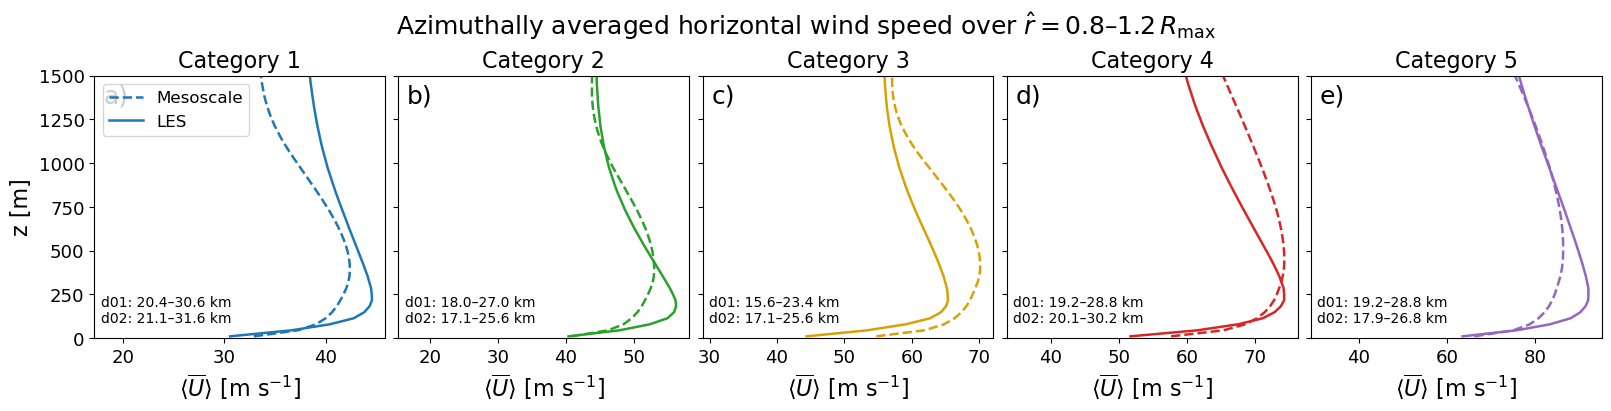

In [18]:
outfile = "UV_vertical_profiles_rhat08_12.png"
letters = ["a)", "b)", "c)", "d)", "e)"]

fig, axes = plt.subplots(
    1, len(SIM_NAMES),
    figsize=(16, 4),
    sharey=True,
    constrained_layout=True
)

# Ensure axes is iterable if only one panel
if len(SIM_NAMES) == 1:
    axes = [axes]

for i, sim in enumerate(SIM_NAMES):
    color = PANEL_COLORS[i]

    with open_case(sim, "d01") as ds_d01, open_case(sim, "d02") as ds_d02:
        rmin_d01_m, rmax_d01_m = get_rhat_band_m(sim, "d01")
        rmin_d02_m, rmax_d02_m = get_rhat_band_m(sim, "d02")

        # Horizontal wind speed (UV)
        z1_uv, uv1 = radial_azimuthal_mean_profile(ds_d01, "UV", "d01", rmin_d01_m, rmax_d01_m)
        z2_uv, uv2 = radial_azimuthal_mean_profile(ds_d02, "UV", "d02", rmin_d02_m, rmax_d02_m)
        z_uv, uv1i, uv2i = interp_to_common_z(z1_uv, uv1, z2_uv, uv2)

        ax = axes[i]
        ax.plot(
            uv1i, z_uv,
            linestyle=DOMAIN_INFO["d01"]["linestyle"],
            color=color,
            linewidth=1.8,
            label="Mesoscale"
        )
        ax.plot(
            uv2i, z_uv,
            linestyle=DOMAIN_INFO["d02"]["linestyle"],
            color=color,
            linewidth=1.8,
            label="LES"
        )

        ax.set_title(PANEL_TITLES[i], fontsize=16)
        ax.text(0.03, 0.97, letters[i], transform=ax.transAxes,
                ha="left", va="top", fontsize=18)

        ax.tick_params(labelsize=13)
        ax.set_xlabel(r"$\langle \overline{U} \rangle$ [m s$^{-1}$]", fontsize=16)
        ax.set_ylim(0, YMAX_PROFILE_M)

        if i == 0:
            ax.set_ylabel("z [m]", fontsize=16)
            ax.legend(frameon=True, fontsize=12)

        # annotate averaging band
        ax.text(
            0.47, 0.05,
            f"d01: {RHAT_MIN * RMAX_WIND_KM[sim]['d01']:.1f}–{RHAT_MAX * RMAX_WIND_KM[sim]['d01']:.1f} km\n"
            f"d02: {RHAT_MIN * RMAX_WIND_KM[sim]['d02']:.1f}–{RHAT_MAX * RMAX_WIND_KM[sim]['d02']:.1f} km",
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10
        )

fig.suptitle(
    rf"Azimuthally averaged horizontal wind speed over "
    rf"$\hat{{r}}={RHAT_MIN:.1f}$–{RHAT_MAX:.1f}$\,R_{{\max}}$",
    fontsize=18
)

fig.savefig(outfile, dpi=200, bbox_inches="tight")
plt.show()